In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rohiteng/amazon-sales-dataset/Amazon.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/kaggle/input/datasets/rohiteng/amazon-sales-dataset/Amazon.csv')
df.head(50)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411
5,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,0.00,215.87,2.74,2017.53,UPI,Delivered,Los Angeles,CA,United States,SELL01494
6,ORD0000007,2024-09-20,CUST037667,Aarav Verma,P00030,Dress Shirt,Clothing,UrbanStyle,2,219.81,0.20,28.14,14.97,394.81,UPI,Delivered,Chicago,IL,Australia,SELL01676
7,ORD0000008,2022-11-10,CUST031165,Rohit Kumar,P00028,Jeans,Toys & Games,KiddoFun,2,306.51,0.05,29.12,6.24,617.73,Debit Card,Pending,Denver,CO,India,SELL00510
8,ORD0000009,2024-06-26,CUST026965,Aman Kapoor,P00031,Kids Toy Car,Sports & Outdoors,Apex,4,146.09,0.00,46.75,7.03,638.14,Debit Card,Delivered,Washington,DC,United States,SELL01895
9,ORD0000010,2020-05-01,CUST029472,Aarav Reddy,P00001,Wireless Earbuds,Clothing,Apex,2,278.21,0.10,60.09,4.88,565.75,Credit Card,Delivered,Houston,TX,United States,SELL01584


In [4]:
print('Shape:',df.shape)

Shape: (100000, 20)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

In [6]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [7]:
df.columns.tolist()

['OrderID',
 'OrderDate',
 'CustomerID',
 'CustomerName',
 'ProductID',
 'ProductName',
 'Category',
 'Brand',
 'Quantity',
 'UnitPrice',
 'Discount',
 'Tax',
 'ShippingCost',
 'TotalAmount',
 'PaymentMethod',
 'OrderStatus',
 'City',
 'State',
 'Country',
 'SellerID']

In [8]:
print('\n__Data Cleaning__')

print('Missing Values:\n', df.isnull().sum())


__Data Cleaning__
Missing Values:
 OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64


In [9]:
print('Duplicate Values:\n', df.duplicated().sum())

Duplicate Values:
 0


In [10]:
df['OrderDate']=pd.to_datetime(df['OrderDate'])
df['Year']= df['OrderDate'].dt.year
df['Month']=df['OrderDate'].dt.month

In [11]:

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2


In [12]:
print('Negative Values')
print('TotalAmount:', (df['TotalAmount']<0).sum())
print('Quantity:', (df['Quantity']<0).sum())

Negative Values
TotalAmount: 0
Quantity: 0


In [13]:
# fix datatype
df['Quantity']= df['Quantity'].astype(int)

In [14]:
df.shape

(100000, 22)

In [15]:
# STEP 4: MEANINGFUL QUESTIONS
# ================================================
# Q1: Which category generates most sales?
# Q2: Which payment method is most popular?
# Q3: How many orders cancelled or returned?
# Q4: Which country has most orders?
# Q5: Does discount affect total amount?

In [16]:
print('Top category: ', df['Category'].value_counts().idxmax())
print('Top Payment Method: ', df['PaymentMethod'].value_counts().idxmax())
print('Cancelled: ', len(df[df['OrderStatus']=='Cancelled']))
print('Returned: ', len(df[df['OrderStatus']=='Returned']))
print('Top Country: ', df['Country'].value_counts().idxmax())
print(' Discount & TotalAmount Correlation: ', round(df['Discount'].corr(df['TotalAmount']),3))

Top category:  Electronics
Top Payment Method:  Credit Card
Cancelled:  3028
Returned:  3049
Top Country:  United States
 Discount & TotalAmount Correlation:  -0.108


In [17]:
df[["Discount", "TotalAmount"]].corr()

,Discount,TotalAmount
Discount,1.000000,-0.108088
TotalAmount,-0.108088,1.000000


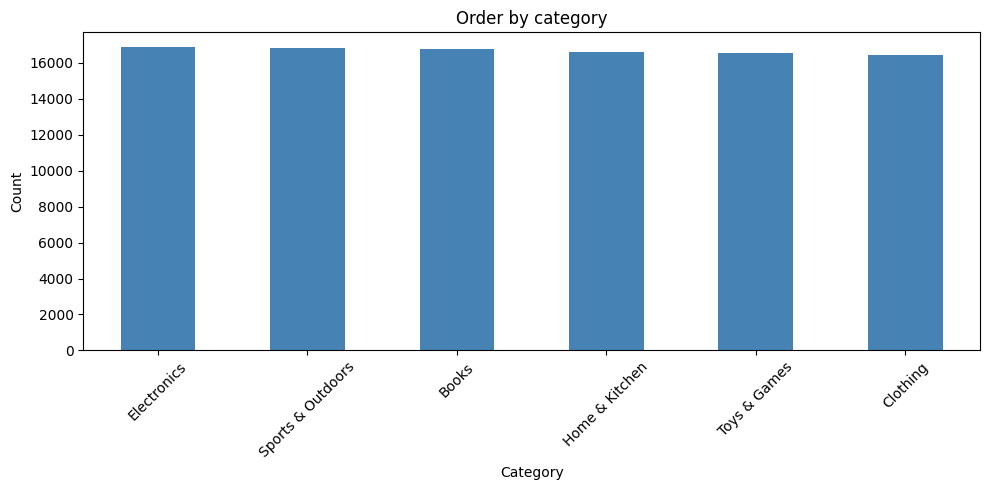

In [18]:
#orders by category
plt.figure(figsize=(10,5))
df['Category'].value_counts().plot(kind='bar' , color='steelblue')
plt.title('Order by category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


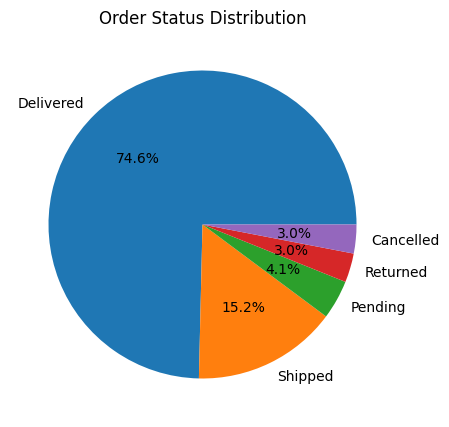

In [19]:
#order status pie chart
plt.figure(figsize=(7, 5))
df['OrderStatus'].value_counts().plot(kind='pie' , autopct='%1.1f%%')
plt.title('Order Status Distribution')
plt.ylabel('')
plt.show()

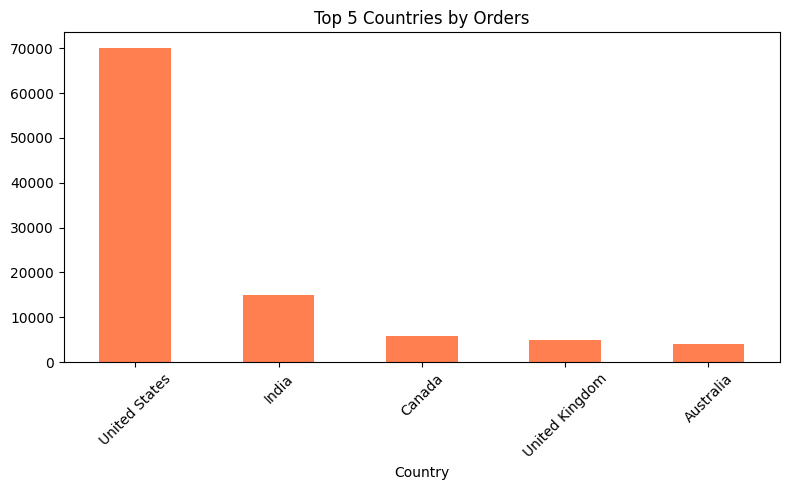

In [20]:
#top countries by order
plt.figure(figsize=(8, 5))
df['Country'].value_counts().head(5).plot(kind='bar', color='coral')
plt.title('Top 5 Countries by Orders')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

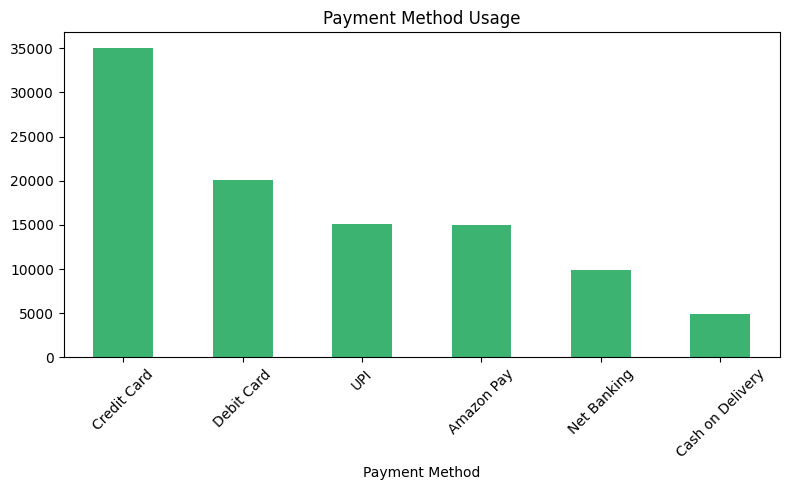

In [21]:
#payment method
plt.figure(figsize=(8, 5))
df['PaymentMethod'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

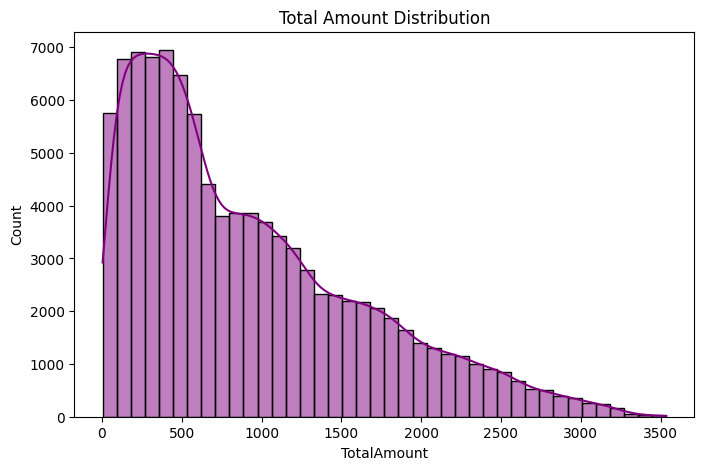

In [22]:
#total amount distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalAmount'], bins=40, kde=True, color='purple')
plt.title('Total Amount Distribution')
plt.show()

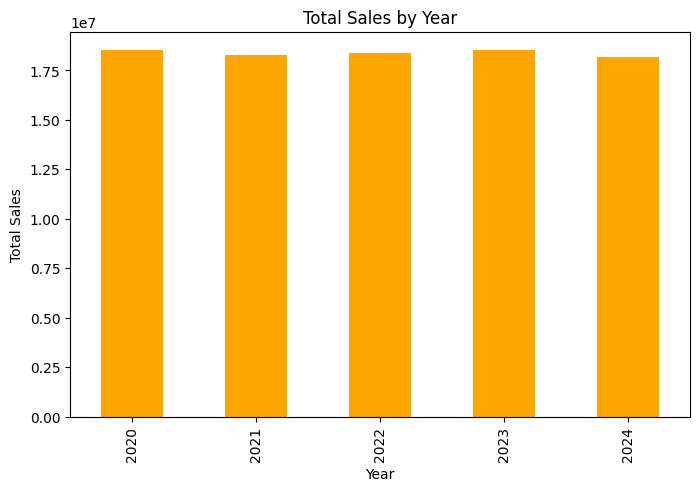

In [23]:
#sales by year
plt.figure(figsize=(8, 5))
df.groupby('Year')['TotalAmount'].sum().plot(kind='bar', color='orange')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

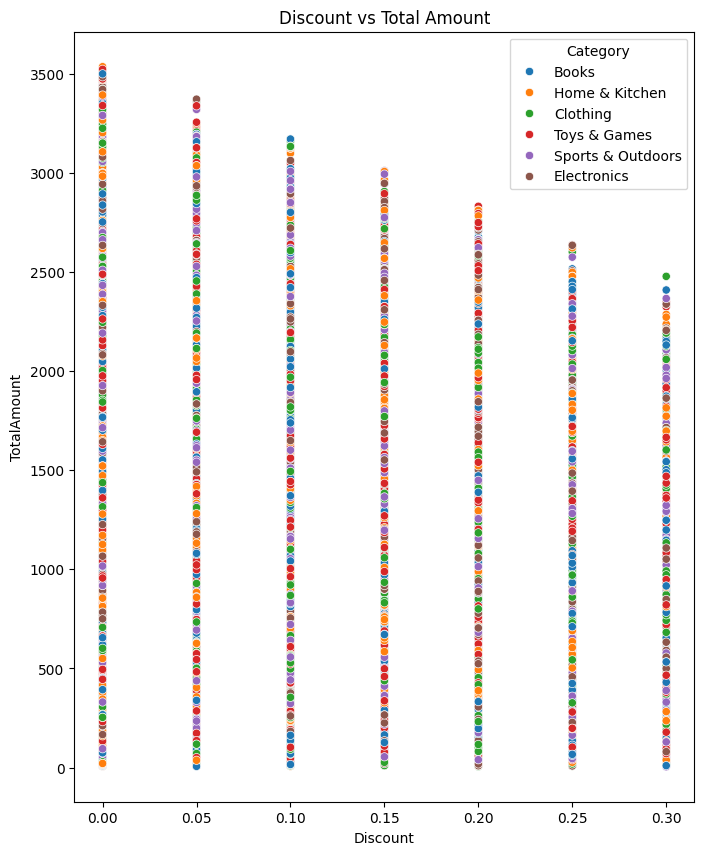

In [24]:
#discount vs total Amount
plt.figure(figsize=(8, 10))
sns.scatterplot(x='Discount', y='TotalAmount', data= df, hue='Category')
plt.title('Discount vs Total Amount')
plt.show()

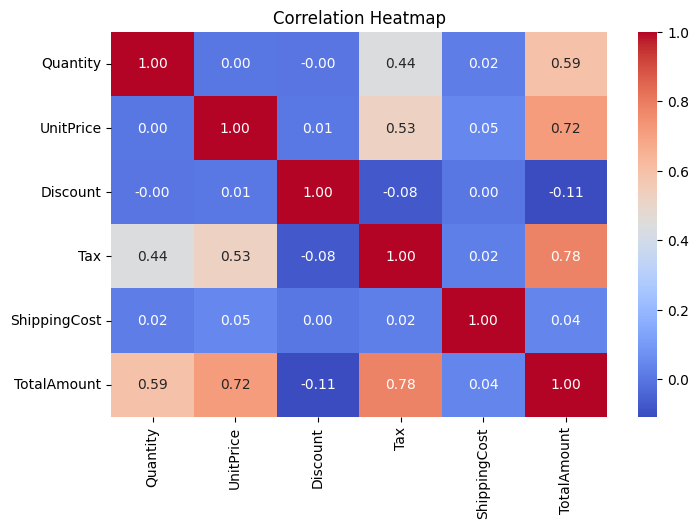

In [25]:
#Correlation Heatmap
plt.figure(figsize=(8, 5))
num_cols=df[['Quantity', 'UnitPrice','Discount','Tax','ShippingCost','TotalAmount']]
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [27]:
# Hypothesis testing
print('Hypothesis1: Discount and TotalAmount Relationship')
corr1=df['Discount'].corr(df['TotalAmount'])
print('Discount vs TotalAmount:', round(corr1,3))

corr2=df['Discount'].corr(df['Quantity'])
print('Discount vs Quantity:', round(corr2,3))




Hypothesis1: Discount and TotalAmount Relationship
Discount vs TotalAmount: -0.108
Discount vs Quantity: -0.0


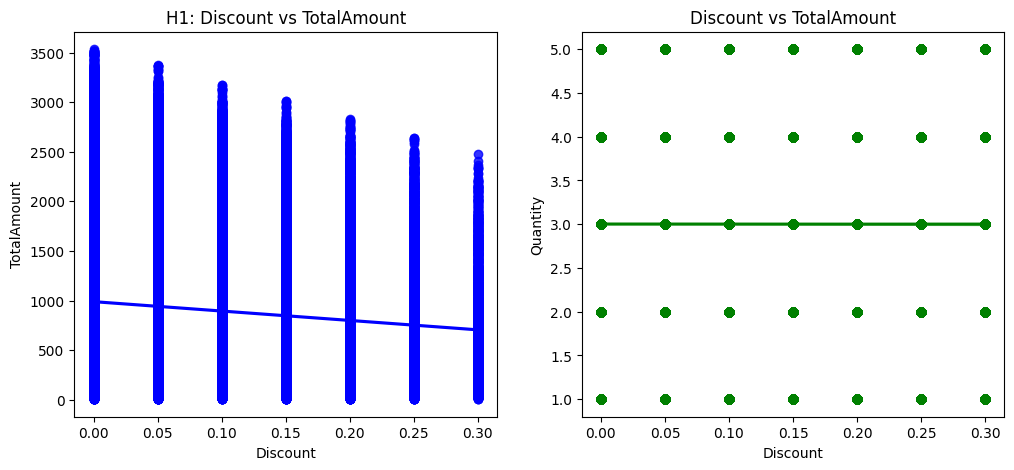

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x='Discount', y='TotalAmount', data=df, ax=axes[0], color='blue')
axes[0].set_title('H1: Discount vs TotalAmount')
sns.regplot(x='Discount', y='Quantity', data=df, ax=axes[1], color='green')
axes[1].set_title('Discount vs TotalAmount')


plt.show()


In [36]:
#Highest sale category 
print('Hypothesis2: highest Sale category (Electronics)')
cate_sales=df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print(cate_sales)
top_cate= cate_sales.idxmax()
if top_cate == 'Electronics':
    print('True :Electronics')
else:
    print(f'false...: {top_cate}')

Hypothesis2: highest Sale category (Electronics)
Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64
True :Electronics


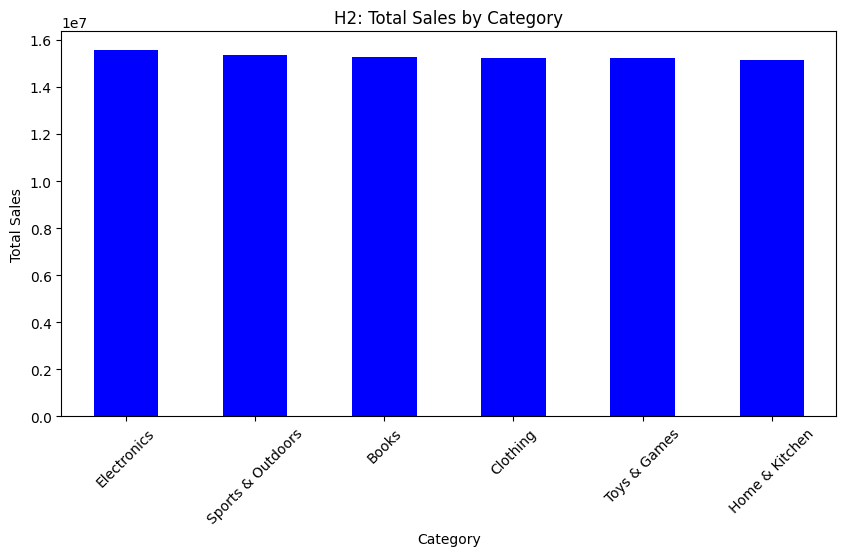

In [34]:
#Graph
plt.figure(figsize=(10,5))
cate_sales.plot(kind='bar', color='blue')
plt.title('H2: Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [37]:
print("\n--- H3: USA Has Most Orders? ---")
country_orders = df['Country'].value_counts()
print(country_orders)
top_country = country_orders.idxmax()

if top_country == 'United States':
    print(" H3 TRUE: USA me sabse zyada orders hain")
else:
    print(f" H3 FALSE: Sabse zyada orders hain → {top_country}")


--- H3: USA Has Most Orders? ---
Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Name: count, dtype: int64
 H3 TRUE: USA me sabse zyada orders hain


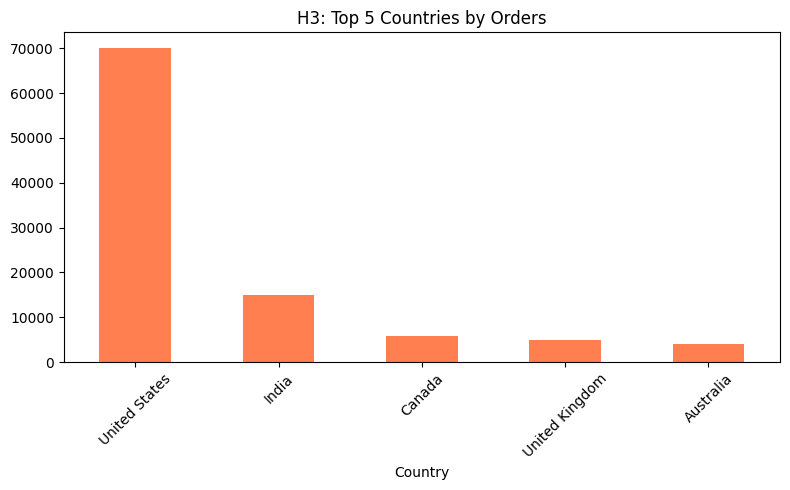

In [38]:
plt.figure(figsize=(8,5))
country_orders.head(5).plot(kind='bar', color='coral')
plt.title('H3: Top 5 Countries by Orders')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
print("Hypothesis4: CAsh on delivery= most cancellation?")
cancelled=df[df["OrderStatus"]== 'Cancelled']
pay_cancellations=cancelled['PaymentMethod'].value_counts()
print(pay_cancellations)
top_cancel=pay_cancellations.idxmax()

if top_cancel== 'Cash on Delivery':
    print('Hypothesis True')
else:
    print('\nHypothesis False')


Hypothesis4: CAsh on delivery= most cancellation?
PaymentMethod
Credit Card         1083
Debit Card           593
Amazon Pay           461
UPI                  444
Net Banking          291
Cash on Delivery     156
Name: count, dtype: int64

Hypothesis False


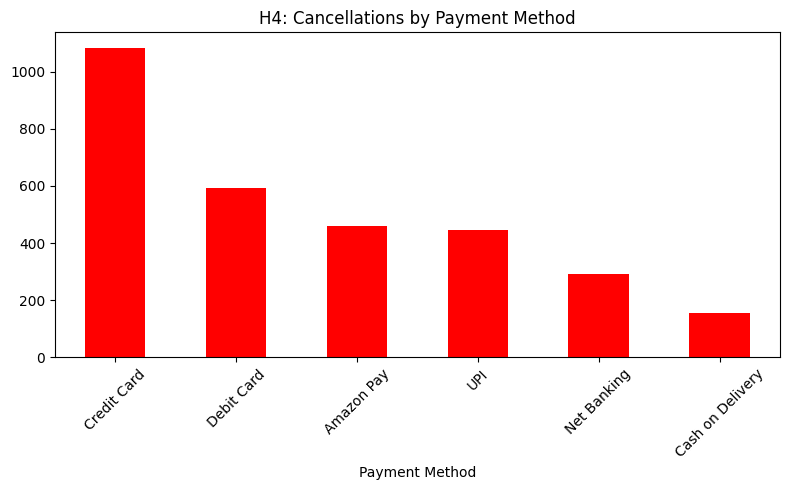

In [46]:
plt.figure(figsize=(8,5))
pay_cancellations.plot(kind='bar', color='red')
plt.title('H4: Cancellations by Payment Method')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2



--- H5: Quantity & Shipping Cost Relationship ---
Correlation Value: 0.02
 H5 TRUE: Zyada quantity = Zyada shipping cost


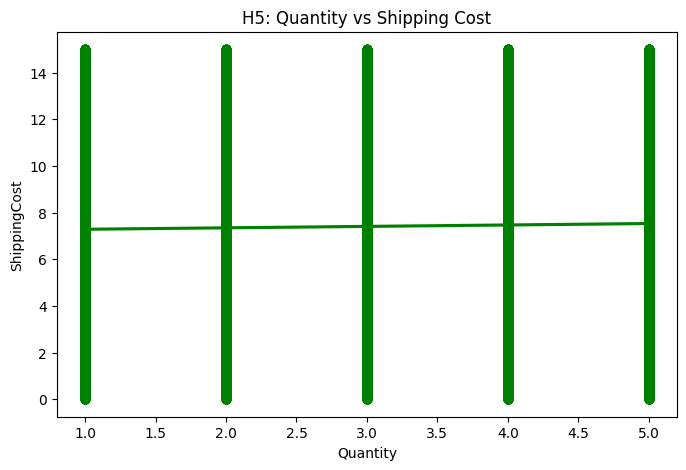

In [48]:
print("\n--- H5: Quantity & Shipping Cost Relationship ---")
corr2 = df['Quantity'].corr(df['ShippingCost'])
print("Correlation Value:", round(corr2, 3))

if corr2 > 0:
    print(" H5 TRUE: Zyada quantity = Zyada shipping cost")
else:
    print(" H5 FALSE: Quantity ka shipping cost pe positive effect nahi")

# Graph
plt.figure(figsize=(8,5))
sns.regplot(x='Quantity', y='ShippingCost', data=df, color='green')
plt.title('H5: Quantity vs Shipping Cost')
plt.show()

In [52]:
#Anomalies
zero_tax= df[(df['Tax']==0) & (df['TotalAmount']>500)]
print('Orders with zero tax but high amount:', len(zero_tax))
zero_tax

Orders with zero tax but high amount: 5839


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month
16,ORD0000017,2023-01-28,CUST000735,Arjun Kumar,P00025,Running Shoes,Home & Kitchen,Zenith,4,453.47,...,4.39,1636.88,Amazon Pay,Delivered,Philadelphia,PA,United States,SELL01971,2023,1
17,ORD0000018,2022-05-21,CUST038237,Anjali Verma,P00039,Graphic Tablet,Toys & Games,KiddoFun,5,547.58,...,10.06,2747.96,Amazon Pay,Delivered,Seattle,WA,United States,SELL00132,2022,5
45,ORD0000046,2022-09-02,CUST045893,Rohit Kapoor,P00009,Portable SSD 1TB,Toys & Games,HomeEase,2,449.14,...,5.62,858.99,Debit Card,Delivered,New York,NY,United States,SELL00181,2022,9
50,ORD0000051,2022-08-15,CUST048348,Sneha Reddy,P00047,Memory Card 128GB,Books,FitLife,3,244.83,...,8.07,558.94,Cash on Delivery,Delivered,San Jose,CA,Australia,SELL00078,2022,8
96,ORD0000097,2020-06-10,CUST049557,Anjali Sharma,P00048,Wireless Charger,Books,NexPro,3,548.17,...,2.63,1564.91,UPI,Delivered,Fort Worth,TX,United States,SELL00108,2020,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99924,ORD0099925,2022-09-24,CUST023164,Mohit Verma,P00027,Winter Jacket,Clothing,FitLife,4,487.36,...,3.74,1563.29,Amazon Pay,Delivered,San Antonio,TX,United Kingdom,SELL01222,2022,9
99928,ORD0099929,2024-11-21,CUST042554,Simran Kumar,P00026,Sunglasses,Clothing,KiddoFun,3,436.63,...,5.69,1315.58,Net Banking,Delivered,New York,NY,United States,SELL00973,2024,11
99982,ORD0099983,2023-03-15,CUST034834,Aarav Mehta,P00015,Instant Pot,Toys & Games,Zenith,4,238.68,...,1.30,956.02,Credit Card,Shipped,Houston,TX,United States,SELL00073,2023,3
99988,ORD0099989,2023-12-23,CUST037839,Aarav Kapoor,P00012,Noise Cancelling Headphones,Home & Kitchen,Zenith,3,218.41,...,4.17,626.64,Debit Card,Delivered,Washington,DC,United States,SELL01002,2023,12


In [53]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[df['UnitPrice'] > Q3 + 1.5 * IQR]
print(f"Price Outliers: {len(outliers)}")
print(outliers[['ProductName', 'UnitPrice']])

Price Outliers: 0
Empty DataFrame
Columns: [ProductName, UnitPrice]
Index: []


In [54]:
print('Sample Category-Product Check:')
print(df[['ProductName','Category']].head(10))

Sample Category-Product Check:
           ProductName           Category
0           Drone Mini              Books
1           Microphone     Home & Kitchen
2  Power Bank 20000mAh           Clothing
3       Webcam Full HD     Home & Kitchen
4              T-Shirt           Clothing
5         Cookware Set              Books
6          Dress Shirt           Clothing
7                Jeans       Toys & Games
8         Kids Toy Car  Sports & Outdoors
9     Wireless Earbuds           Clothing
